In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Week 7: Random Forests")

Week 7: Random Forests


In [87]:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (50000, 31)
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly']


In [88]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing values: 0
Shape: (50000, 30)


In [89]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 45)
Target: (50000,)


In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 45)
Testing data: (10000, 45)


In [91]:
rf = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("OOB Accuracy:", rf.oob_score_)

Random Forest Accuracy: 0.7903
OOB Accuracy: 0.791875


In [92]:
n_estimators_list = [10, 25, 50, 100, 150, 200]

oob_errors = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    oob_errors.append(1 - model.oob_score_)

for n, error in zip(n_estimators_list, oob_errors):
    print("Trees:", n, "OOB Error:", error)

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Trees: 10 OOB Error: 0.25585
Trees: 25 OOB Error: 0.224225
Trees: 50 OOB Error: 0.216275
Trees: 100 OOB Error: 0.21132499999999999
Trees: 150 OOB Error: 0.21002500000000002
Trees: 200 OOB Error: 0.208125


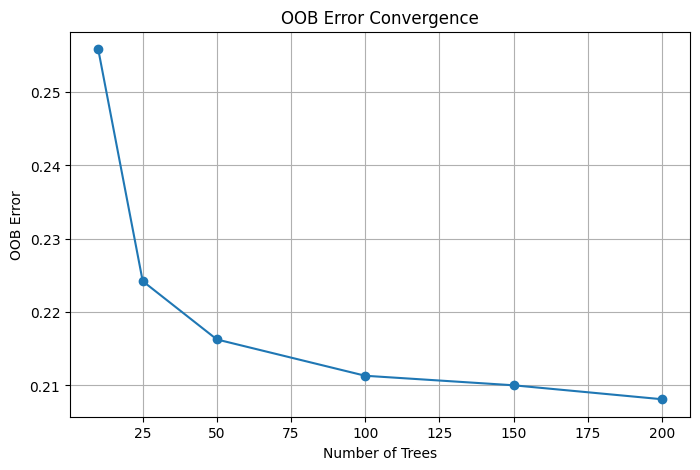

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(n_estimators_list, oob_errors, marker='o')

plt.title("OOB Error Convergence")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.grid(True)

plt.show()

In [96]:
max_features_values = ['sqrt', 'log2', None]
feature_results = []

for value in max_features_values:
    model = RandomForestClassifier(
        n_estimators=20,
        max_features=value,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    feature_results.append({
        'max_features': str(value),
        'Accuracy': accuracy_score(y_test, pred)
    })

feature_results = pd.DataFrame(feature_results)

print(feature_results)

  max_features  Accuracy
0         sqrt    0.7888
1         log2    0.7894
2         None    0.7887


In [97]:
tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

rf_pred = rf.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Decision Tree Accuracy: 0.7753
Random Forest Accuracy: 0.7903


In [100]:
# Fast Feature Importance

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

Top 10 Important Features:
CGPA               0.115629
SGPA_Sem8          0.081755
SGPA_Sem4          0.061922
SGPA_Sem7          0.061390
SGPA_Sem3          0.059856
SGPA_Sem5          0.058502
SGPA_Sem2          0.056487
SGPA_Sem1          0.055419
SGPA_Sem6          0.048073
CodingTestScore    0.045168
dtype: float64
